# Ecommerce Linear Regression Project

This notebook covers an end-to-end **Linear Regression** use case using ecommerce data.

## Objective
Predict **sales_amount** based on:
- categorical features
- numerical features
- basic preprocessing
- model training
- evaluation
- prediction on new input

---


## Task 1: Import libraries

Load all required Python libraries for:
- data handling
- preprocessing
- model building
- evaluation


In [1]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

import matplotlib.pyplot as plt


## Task 2: Read the ecommerce CSV file

In [2]:
df = pd.read_csv("ecommerce_regression_data.csv")
df.head()


,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
0,Beauty,Regular,UPI,1,33,1832.03,4.1,0,1,1307.65
1,Electronics,Prime,Wallet,8,30,3331.92,3.9,2,1,2605.51
2,Home,Business,UPI,7,22,2531.15,4.5,2,0,2530.16
3,Electronics,Regular,UPI,5,36,2245.48,4.0,2,0,1719.26
4,Fashion,Regular,Card,5,5,2404.44,3.9,3,0,2131.67


## Task 3: Check shape and column names

In [4]:
df.shape

(1000, 10)

In [5]:
df.columns

Index(['product_category', 'customer_segment', 'payment_method', 'units_sold',
       'discount_pct', 'ad_spend', 'customer_rating', 'returns_count',
       'is_festival_season', 'sales_amount'],
      dtype='str')

## Task 4: Explore dataset information and missing values

In [7]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 10 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   product_category    990 non-null    str    
 1   customer_segment    990 non-null    str    
 2   payment_method      990 non-null    str    
 3   units_sold          1000 non-null   int64  
 4   discount_pct        1000 non-null   int64  
 5   ad_spend            985 non-null    float64
 6   customer_rating     985 non-null    float64
 7   returns_count       1000 non-null   int64  
 8   is_festival_season  1000 non-null   int64  
 9   sales_amount        1000 non-null   float64
dtypes: float64(3), int64(4), str(3)
memory usage: 97.9 KB


In [8]:
df.isnull().sum

<bound method DataFrame.sum of      product_category  customer_segment  payment_method  units_sold  \
0               False             False           False       False   
1               False             False           False       False   
2               False             False           False       False   
3               False             False           False       False   
4               False             False           False       False   
..                ...               ...             ...         ...   
995             False             False           False       False   
996             False             False           False       False   
997             False             False           False       False   
998             False             False           False       False   
999             False             False           False       False   

     discount_pct  ad_spend  customer_rating  returns_count  \
0           False     False            False         

## Task 5: Summary statistics

In [9]:
df.describe(include='all')

,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season,sales_amount
count,990,990,990,1000.000000,1000.000000,985.000000,985.000000,1000.000000,1000.000000,1000.000000
unique,5,3,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,Electronics,Regular,NetBanking,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,287,625,282,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,NaN,NaN,NaN,5.531000,19.874000,2430.335766,4.105076,1.438000,0.225000,2146.947540
std,NaN,NaN,NaN,2.878076,11.948678,911.384942,0.488771,1.124019,0.417791,552.016871
min,NaN,NaN,NaN,1.000000,0.000000,200.000000,2.600000,0.000000,0.000000,423.460000
25%,NaN,NaN,NaN,3.000000,10.000000,1832.030000,3.800000,0.000000,0.000000,1764.660000
50%,NaN,NaN,NaN,6.000000,20.000000,2464.260000,4.100000,1.000000,0.000000,2141.540000
75%,NaN,NaN,NaN,8.000000,30.000000,3052.840000,4.500000,2.000000,0.000000,2550.967500


## Task 6: Define target and input features

Target column:
- `sales_amount`

Input columns:
- all remaining columns


In [12]:
y = df["sales_amount"]

X = df.drop("sales_amount", axis=1)

X.head()


,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season
0,Beauty,Regular,UPI,1,33,1832.03,4.1,0,1
1,Electronics,Prime,Wallet,8,30,3331.92,3.9,2,1
2,Home,Business,UPI,7,22,2531.15,4.5,2,0
3,Electronics,Regular,UPI,5,36,2245.48,4.0,2,0
4,Fashion,Regular,Card,5,5,2404.44,3.9,3,0


In [13]:
y.head()

0    1307.65
1    2605.51
2    2530.16
3    1719.26
4    2131.67
Name: sales_amount, dtype: float64

## Task 7: Build preprocessing pipelines

### For categorical columns
- fill missing values with most frequent value
- apply one-hot encoding

### For numerical columns
- fill missing values with median


In [14]:
categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()
numerical_cols = X.select_dtypes(exclude=["object"]).columns.tolist()

categorical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])


numerical_pipeline = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median"))
])

preprocessor = ColumnTransformer(transformers=[
    ("cat", categorical_pipeline, categorical_cols),
    ("num", numerical_pipeline, numerical_cols)
])

C:\Users\Nallabothula.Naidu\AppData\Local\Temp\ipykernel_41404\2854090741.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  categorical_cols = X.select_dtypes(include=["object"]).columns.tolist()


## Task 8: Split data into train and test sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

X_train.shape

(800, 9)

In [17]:
X_test.shape


(200, 9)

In [18]:
y_train.shape


(800,)

In [19]:
y_test.shape

(200,)

## Task 9: Create Linear Regression model pipeline

In [20]:
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("regressor", LinearRegression())
])

## Task 10: Make predictions on test data

In [22]:
model.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessor', ...), ('regressor', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('cat', ...), ('num', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformer

In [23]:
y_pred = model.predict(X_test)
y_pred

array([1804.54826353, 2304.21306778, 2586.9932135 , 2389.69187315,
       1922.27164431, 2060.02732382, 1804.96094716, 2746.02035391,
       2550.87903454, 2273.44303381, 1965.57304533, 1760.85037861,
       1673.82363706, 1718.80375384, 1410.29562606, 2336.38904245,
        952.42514238, 1274.3960971 , 2702.20585979, 1885.94277783,
       2499.43827316, 1733.06468075, 3523.73281655, 2029.13889149,
       1778.12664957, 2718.19802067, 2455.30191319, 1788.30833696,
       1943.73087325, 1852.55366901, 2637.01962026, 1553.92579154,
       2056.46100553, 1499.57451321, 1849.4601511 , 1456.29753617,
       2119.0381011 , 1692.81480293, 1650.90134455, 1822.75546543,
       2004.9203548 , 2082.96726288, 1397.56620151, 1704.51087969,
       1757.88487342, 2591.07916541, 1751.13396152, 2356.71460587,
       1844.66344563, 1937.62082647, 2865.71016246, 2656.74378457,
       1810.30519348, 2709.25308822, 2758.88349458, 2339.67403929,
       1857.07123512, 2163.34559628, 2355.61320937, 1376.36913

## Task 11: Evaluate the model

In [25]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = mse ** 0.5
r2 = r2_score(y_test, y_pred)

In [26]:
mae


98.42116563986325

In [27]:
mse


17157.806557635668

In [28]:
rmse


130.9878107215922

In [29]:
r2

0.9445549016209389

## Task 12: Visualize Actual vs Predicted

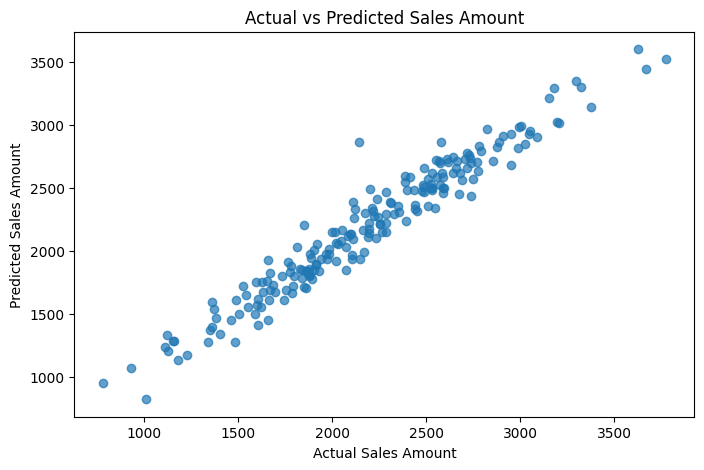

In [30]:
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, alpha=0.7)
plt.xlabel("Actual Sales Amount")
plt.ylabel("Predicted Sales Amount")
plt.title("Actual vs Predicted Sales Amount")
plt.show()

## Task 13: Residual analysis

In [32]:
pip install seaborn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [33]:
import seaborn as sns


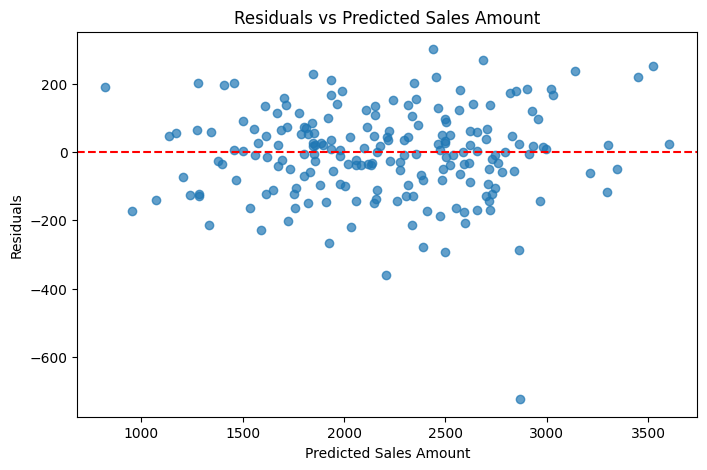

In [35]:
residuals = y_test - y_pred

plt.figure(figsize=(8, 5))
plt.scatter(y_pred, residuals, alpha=0.7)
plt.axhline(y=0, color='red', linestyle='--')
plt.xlabel("Predicted Sales Amount")
plt.ylabel("Residuals")
plt.title("Residuals vs Predicted Sales Amount")
plt.show()

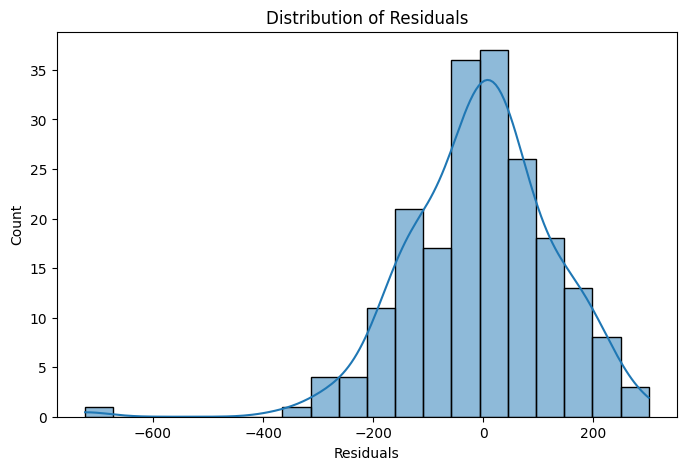

In [36]:
plt.figure(figsize=(8, 5))
sns.histplot(residuals, kde=True)
plt.xlabel("Residuals")
plt.title("Distribution of Residuals")
plt.show()

## Task 14: Predict sales for a new ecommerce record

In [38]:
new_record = pd.DataFrame([{
    "product_category": "Beauty",
    "customer_segment": "Regular",
    "payment_method": "UPI",
    "units_sold": 5,
    "discount_pct": 10,
    "ad_spend": 3000.0,
    "customer_rating": 4.2,
    "returns_count": 0,
    "is_festival_season": 1
}])

new_record

,product_category,customer_segment,payment_method,units_sold,discount_pct,ad_spend,customer_rating,returns_count,is_festival_season
0,Beauty,Regular,UPI,5,10,3000.0,4.2,0,1


In [39]:
new_pred = model.predict(new_record)
new_pred

array([2609.80582395])